# Aula 08: Por Dentro da Caixa (Bounding Boxes) 📦

Hoje vamos entender o que o YOLO realmente nos devolve e como usar esses números para criar nossas próprias visualizações.

## 1. O que é uma Bounding Box (Caixa Delimitadora)?

Quando o YOLO detecta um objeto, ele não retorna "uma imagem com um quadrado". Ele retorna **números** que descrevem onde esse quadrado está.

Existem dois formatos principais para representar esses quadrados:

### 1.1 Formato XYXY (Padrão do YOLOv8 quando usamos `boxes.xyxy`)
É o formato mais fácil de plotar:
*   **x1 (xmin)**: Coordenada X do canto **esquerdo superior**.
*   **y1 (ymin)**: Coordenada Y do canto **esquerdo superior**.
*   **x2 (xmax)**: Coordenada X do canto **direito inferior**.
*   **y2 (ymax)**: Coordenada Y do canto **direito inferior**.

### 1.2 Formato XYWH (Comum para cálculos de centro)
*   **x_centro**: O meio da caixa no eixo X.
*   **y_centro**: O meio da caixa no eixo Y.
*   **width (largura)**: Largura total da caixa.
*   **height (altura)**: Altura total da caixa.

## 2. Confiança e Classes

Além da posição, cada detecção traz:
*   **Confiança (conf)**: Um número entre 0.0 e 1.0 (ou 0% a 100%) que diz o "quanto" o modelo tem certeza. Geralmente filtramos tudo abaixo de 0.5 (50%).
*   **Classe (cls)**: Um número inteiro (ID) que representa o objeto (0=pessoa, 1=bicicleta, 2=carro...). O modelo tem uma lista interna de nomes (`names`) para traduzir isso.

## 3. Preparando o Ambiente

Esta aula assume que você está dentro do ambiente virtual da `aula-08`.

Se ainda não instalou as dependências necessárias, execute no terminal:

```bash
poetry add ultralytics numpy opencv-python requests
poetry add --dev jupyter ipykernel
poetry run python -m ipykernel install --user --name aula-08 --display-name "aula-08 (poetry)"
```

## 4. Prática: Desenhando "Na Mão"

Para provar que não existe mágica, vamos rodar o YOLO, pegar os números brutos e desenhar nós mesmos usando a biblioteca OpenCV, que aprendemos na Aula 03.

In [2]:
from ultralytics import YOLO, settings
import cv2
import requests
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 0. Configurações
settings.update({'runs_dir': './runs'})

In [4]:
# 1. Carregar Modelo
model = YOLO('yolov8n.pt')

# 2. Carregar Imagem com OpenCV
imagem_path = "zidane.jpg"

In [5]:
# Download da imagem se não existir
try:
    img = cv2.imread(imagem_path)
    if img is None:
        raise FileNotFoundError
except (FileNotFoundError, Exception):
    print("Imagem não encontrada! Baixando...")
    img_data = requests.get('https://ultralytics.com/images/zidane.jpg').content
    with open('zidane.jpg', 'wb') as handler:
        handler.write(img_data)
    img = cv2.imread('zidane.jpg')

In [6]:
# 3. Inferência (Sem salvar, sem mostrar)
# verbose=False deixa o terminal mais limpo
results = model(img, verbose=True)

# results é uma lista (pois poderíamos ter passado várias imagens).
# Pegamos o primeiro (e único) resultado.
resultado = results[0]


0: 384x640 2 persons, 1 tie, 94.1ms
Speed: 7.5ms preprocess, 94.1ms inference, 4.2ms postprocess per image at shape (1, 3, 384, 640)


In [7]:
# 4. Iterar sobre as detecções
# resultado.boxes contém todas as caixas encontradas
for box in resultado.boxes:
    # Coordenadas: xyxy (x1, y1, x2, y2)
    # Convertemos para inteiros pois pixels não tem vírgula
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    
    # box.conf é um tensor (estrutura do PyTorch) com o score de confiança da detecção.
    # O [0] pega o primeiro (e único) valor do tensor. float() converte para número Python.
    # Valor entre 0.0 e 1.0: quanto mais próximo de 1.0, mais certo o modelo está.
    confianca = float(box.conf[0])

    
    # box.cls é um tensor com o ID numérico da classe detectada (ex: 0=person, 1=bicycle, 2=car...).
    # int([0]) extrai o valor inteiro para usá-lo como índice de dicionário.
    cls_id = int(box.cls[0])
    
    # model.names é um dicionário que mapeia ID → nome legível (ex: {0: 'person', 1: 'bicycle'}).
    # Usamos o cls_id como chave para obter a string com o nome do objeto detectado.
    nome_classe = model.names[cls_id]

    print(f"Detectado: {nome_classe} ({confianca:.2f}) em [{x1}, {y1}, {x2}, {y2}]")

    # 5. Desenhar Retângulo (OpenCV)
    # cv2.rectangle(imagem, ponto_topo_esq, ponto_baixo_dir, cor_bgr, espessura)
    cor = (0, 255, 0) # Verde
    cv2.rectangle(img, (x1, y1), (x2, y2), cor, 2)

    # 6. Escrever Texto
    texto = f"{nome_classe} {confianca:.1%}"
    # Fundo do texto para ler melhor
    cv2.rectangle(img, (x1, y1 - 20), (x1 + 150, y1), cor, -1)
    
    cv2.putText(
        img, 
        texto, 
        (x1, y1 - 5), 
        cv2.FONT_HERSHEY_SIMPLEX, 
        0.6, 
        (0, 0, 0), # Texto Preto
        2
    )

Detectado: person (0.84) em [114, 197, 1114, 711]
Detectado: person (0.82) em [748, 41, 1143, 713]
Detectado: tie (0.29) em [439, 437, 524, 709]


In [8]:
# Função auxiliar para mostrar imagens no Notebook
def mostrar(img, titulo="Imagem"):
    # OpenCV usa BGR, Matplotlib usa RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title(titulo)
    plt.axis('off')
    plt.show()

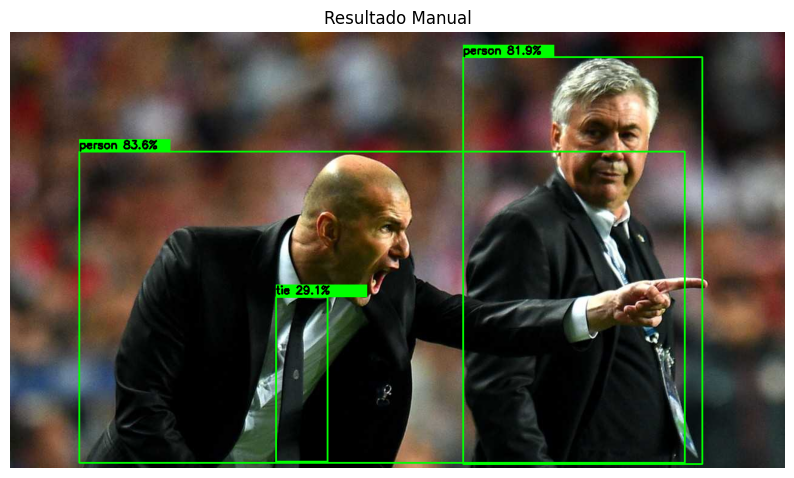

In [9]:
# 7. Mostrar resultado no notebook
mostrar(img, "Resultado Manual")

In [10]:
# OPCIONAL: Salvar em disco
cv2.imwrite("resultado_manual_bbox.png", img)
print("\nImagem salva como 'resultado_manual_bbox.png'.")


Imagem salva como 'resultado_manual_bbox.png'.


## 5. Analise o Resultado

Você verá que criamos exatamente o mesmo resultado que o YOLO cria automaticamente, mas agora você tem **controle total**.
Você pode mudar a cor da caixa se for uma "pessoa", pintar de vermelho se a confiança for baixa, ou recortar a imagem (`crop = img[y1:y2, x1:x2]`) para salvar apenas o rosto.

No próximo projeto, vamos usar esse poder! 🚀

## 6. Por que desenhar manualmente?

Seu objetivo como engenheiro de ML não é apenas gerar uma imagem com quadradinhos coloridos, mas sim **tomar decisões** com base no que o modelo viu.

Aqui estão 4 motivos pelos quais o acesso manual aos dados (`xyxy`) é fundamental:

1.  **Lógica de Negócio (O mais importante)**
    *   O `plot()` apenas desenha pixels. Ele não "sabe" o que está acontecendo.
    *   Com as coordenadas, você pode programar: *"Se o centro da caixa da 'Pessoa' cruzar a linha X=500, incremente o contador de clientes da loja"*.
    *   Ou: *"Se detectar 'Capacete' na cabeça do operário, OK. Se não detectar, toque o alarme de segurança"*.

2.  **Recorte e Reutilização (Crop)**
    *   Imagine um sistema de reconhecimento facial. O YOLO detecta o rosto, você pega as coordenadas (`x1:x2, y1:y2`), **recorta** essa parte da imagem e envia apenas o rosto para outra rede neural identificar *quem* é a pessoa.

3.  **Estética e UX**
    *   O visual padrão do YOLO é ótimo para debug, mas pode ser "feio" para um produto final.
    *   Manualmente, você pode desenhar caixas minimalistas, semitransparentes, ou mudar a cor baseado em critérios (ex: Vermelho para "Perigo", Verde para "Seguro").

4.  **Desempenho**
    *   Em sistemas embarcados (Raspberry Pi, Drones), desenhar na tela consome processamento. Às vezes você quer rodar o modelo, pegar a coordenada para guiar um motor de robô, e não gastar tempo desenhando nada na tela.

Resumindo: O modo automático é para **nós** (humanos) vermos. O modo manual (coordenadas) é para **o sistema** ver e agir.